# F4 · Comunicación de resultados: posiciones, estabilidad y cohesión

## Objetivo
Analizar las posiciones políticas relativas y la estabilidad del comportamiento legislativo de
las diputadas y los diputados, así como las posiciones políticas relativas y el grado de
cohesión de los partidos políticos, a partir de todas las votaciones nominales asociadas al
proyecto de ley sobre protección de datos personales (boletín 11092-07) en la Cámara de
Diputadas y Diputados de Chile.

El notebook responde, en orden, las cuatro preguntas de investigación:

1. **P1.** ¿Qué posiciones políticas relativas presentan las diputadas y los diputados a partir
   de sus patrones de votación durante la tramitación del proyecto de ley?
2. **P2.** ¿Qué grado de estabilidad o variabilidad presenta el comportamiento individual de
   las diputadas y los diputados a lo largo de las votaciones analizadas?
3. **P3.** ¿Qué posiciones políticas relativas presentan los partidos políticos a partir del
   comportamiento de sus integrantes?
4. **P4.** ¿Qué grado de cohesión o dispersión presentan los partidos políticos durante la
   tramitación del proyecto de ley?

## Entradas y organización
El notebook **no estima ningún modelo**: integra las salidas versionadas de F4_01 a F4_05, que
están en `F4/data/results` y `F4/data/reports`:

- B-Call: `bcall_diputados.csv`, perfiles de voto, robustez del pivote y escenarios externos.
- Posición partidaria: `posicion_partidaria.csv`.
- Cohesión: `resumen_cohesion.csv`.
- Afinidad: `hamming_partidos.csv`.
- Contrastes: `resumen_comparacion.csv`, sensibilidad del clustering y del PCA.
- Sensibilidad: `sensibilidad.csv`.
- Universos y conciliación: `universo_por_metodo.csv` y `conciliacion_resultados.json`.

Cada cifra del texto se calcula desde esos archivos y se contrasta con su fuente; ninguna se
escribe a mano. Las figuras se guardan en `F4/figures/comunicacion/`. Las fórmulas y los
diagnósticos completos están en F4_02 (B-Call), F4_03 (partidos y afinidad), F4_04
(clustering y PCA) y F4_05 (cohesión).

### Cautelas de interpretación
- **Eje relativo, no ideológico.** El eje B-Call describe el conflicto observado en este
  corpus; sus lados L y R no son una clasificación ideológica general.
- **Resultados descriptivos.** Sin un padrón verificable de elegibilidad, la ausencia de
  registro no se interpreta como inasistencia, y los resultados no se generalizan más allá
  del corpus.
- **Corpus concentrado en el tiempo.** De las 15 votaciones nominales, 14 ocurrieron en una
  sola sesión. Por eso la estabilidad se mide entre votaciones, no como trayectoria temporal
  (sección 3.1).

In [1]:
import json
import platform
import subprocess
import sys
import tomllib
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

raiz = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / 'pyproject.toml').is_file() and (p / 'F4/src/analisis').is_dir()), None)
if raiz is None:
    raise FileNotFoundError('Ejecuta el notebook dentro del repositorio.')
if str(raiz) not in sys.path:
    sys.path.insert(0, str(raiz))
from F4.src.analisis import visualizacion as vis  # noqa: E402

RESULTADOS, REPORTES = raiz / 'F4/data/results', raiz / 'F4/data/reports'
rutas = {
    'config': raiz / 'F4/config/analisis.toml',
    'decisiones': REPORTES / 'decisiones_metodologicas.json',
    'conciliacion': REPORTES / 'conciliacion_resultados.json',
    'manifiesto': REPORTES / 'manifiesto_corte.json',
    'universo': REPORTES / 'universo_por_metodo.csv',
    'sensibilidad': REPORTES / 'sensibilidad.csv',
    'sensibilidad_clustering': REPORTES / 'sensibilidad_clustering.csv',
    'catalogo': raiz / 'F3/data/processed/proyecto_ley_procesado.csv',
    'bcall': RESULTADOS / 'individual/bcall/bcall_diputados.csv',
    'ejecucion_bcall': RESULTADOS / 'individual/bcall/ejecucion_bcall.json',
    'perfiles': RESULTADOS / 'individual/bcall/perfiles_voto.csv',
    'votaciones_bcall': RESULTADOS / 'individual/bcall/votaciones.csv',
    'robustez_pivote': RESULTADOS / 'individual/bcall/robustez_pivote.csv',
    'posiciones_revision': RESULTADOS / 'individual/bcall/posiciones_revision.csv',
    'posicion': RESULTADOS / 'partidos/posicion_partidaria.csv',
    'resumen_cohesion': RESULTADOS / 'partidos/resumen_cohesion.csv',
    'hamming_partidos': RESULTADOS / 'pares/hamming_partidos.csv',
    'comparacion': RESULTADOS / 'comparacion/resumen_comparacion.csv',
    'sensibilidad_pca': RESULTADOS / 'comparacion/sensibilidad_pca.csv',
}
for nombre, ruta in rutas.items():
    if not ruta.is_file() or ruta.stat().st_size == 0:
        raise FileNotFoundError(f'Entrada ausente o vacía: {ruta.relative_to(raiz)}')
FIGURAS = raiz / 'F4/figures/comunicacion'
FIGURAS.mkdir(parents=True, exist_ok=True)

with rutas['config'].open('rb') as archivo:
    config = tomllib.load(archivo)


def leer_json(nombre):
    return json.loads(rutas[nombre].read_text(encoding='utf-8'))


# Convenciones visuales comunes (F4/src/analisis/visualizacion.py).
vis.aplicar_estilo()
pd.set_option('display.max_columns', 30)
figuras_generadas = []


def guardar(fig, nombre):
    vis.guardar(fig, FIGURAS / nombre, figuras_generadas)


def texto(contenido):
    # Párrafo con cifras calculadas desde los archivos (no escritas a mano).
    display(Markdown(contenido))


def c(valor, decimales=2):
    return vis.coma(float(valor), decimales)


def pct(proporcion, decimales=0):
    return f'{vis.coma(100 * float(proporcion), decimales)} %'


def lectura(numero, muestra, infiero, limite, aporte):
    # Cuatro frases bajo cada figura, listas para copiar al informe.
    texto(f'**Lectura de la figura {numero}.**\n\n'
          f'- **Qué muestra.** {muestra}\n'
          f'- **Qué se infiere.** {infiero}\n'
          f'- **Límite.** {limite}\n'
          f'- **Aporte al relato.** {aporte}')


def lista(elementos):
    elementos = [str(e) for e in elementos]
    return elementos[0] if len(elementos) == 1 else ', '.join(elementos[:-1]) + ' y ' + elementos[-1]

## 1. Corpus, universos y estado del protocolo

### 1.1. Votaciones analizadas
El corpus contiene todas las votaciones nominales en sala del boletín 11092-07 registradas en
el corte F3. La tabla y la figura muestran, para cada votación, la fecha, el trámite, la
disposición votada y los totales oficiales de Sí, No y Abstención.

In [2]:
catalogo = pd.read_csv(rutas['catalogo'])
catalogo['fecha'] = pd.to_datetime(catalogo['Fecha'])
catalogo = catalogo.sort_values(['fecha', 'Id']).reset_index(drop=True)
catalogo['disposicion'] = (catalogo['Articulo'].fillna('Proyecto en general')
                           .str.split(',').str[0].str.strip().str.slice(0, 70))
manifiesto = leer_json('manifiesto')
assert len(catalogo) == manifiesto['entrada']['votaciones'] == catalogo['Id'].nunique()

votaciones_bcall = pd.read_csv(rutas['votaciones_bcall']).set_index('votacion_id')
catalogo['usada_en_bcall'] = catalogo['Id'].map(votaciones_bcall['incluida_por_varianza'])
display(catalogo[['Id', 'fecha', 'TramiteConstitucional', 'disposicion', 'TotalSi',
                  'TotalNo', 'TotalAbstencion', 'Resultado', 'usada_en_bcall']]
        .rename(columns={'Id': 'votacion_id', 'TramiteConstitucional': 'trámite'}))

sesiones = catalogo.groupby(catalogo['fecha'].dt.date)['Id'].agg(['count', 'min', 'max'])
n_votaciones = len(catalogo)
sesion_principal = sesiones['count'].idxmax()
en_sesion_principal = int(sesiones['count'].max())
duracion = (catalogo.loc[catalogo['fecha'].dt.date.eq(sesion_principal), 'fecha']
            .agg(['min', 'max']).diff().iloc[-1])
unanimes = catalogo.loc[catalogo['TotalNo'].eq(0) & catalogo['TotalAbstencion'].eq(0), 'Id']
display(sesiones.rename(columns={'count': 'votaciones', 'min': 'primera', 'max': 'última'}))

,votacion_id,fecha,trámite,disposicion,TotalSi,TotalNo,TotalAbstencion,Resultado,usada_en_bcall
0,20627,2023-05-08 19:05:22,Segundo Trámite,Proyecto en general,122,0,0,Aprobado,False
1,20628,2023-05-08 19:06:49,Segundo Trámite,Letra h) del artículo 3°,128,0,0,Aprobado,False
2,20629,2023-05-08 19:08:21,Segundo Trámite,Encabezado del artículo 14 ter,90,42,3,Aprobado,True
3,20630,2023-05-08 19:09:23,Segundo Trámite,Letra L) del artículo 14 ter,90,40,5,Aprobado,True
4,20631,2023-05-08 19:10:13,Segundo Trámite,Artículo 30,91,43,1,Aprobado,True
5,20632,2023-05-08 19:11:06,Segundo Trámite,Artículo 30 bis,93,42,0,Aprobado,True
6,20633,2023-05-08 19:11:56,Segundo Trámite,Artículo 30 ter,94,39,2,Aprobado,True
7,20634,2023-05-08 19:12:58,Segundo Trámite,Artículo 30 quáter,94,40,1,Aprobado,True
8,20635,2023-05-08 19:13:51,Segundo Trámite,Artículo 30 octies,92,40,3,Aprobado,True
9,20636,2023-05-08 19:15:04,Segundo Trámite,Artículo 30 nonies,92,40,3,Aprobado,True


,votaciones,primera,última
fecha,,,
2023-05-08,14,20627,21219
2024-08-26,1,42724,42724


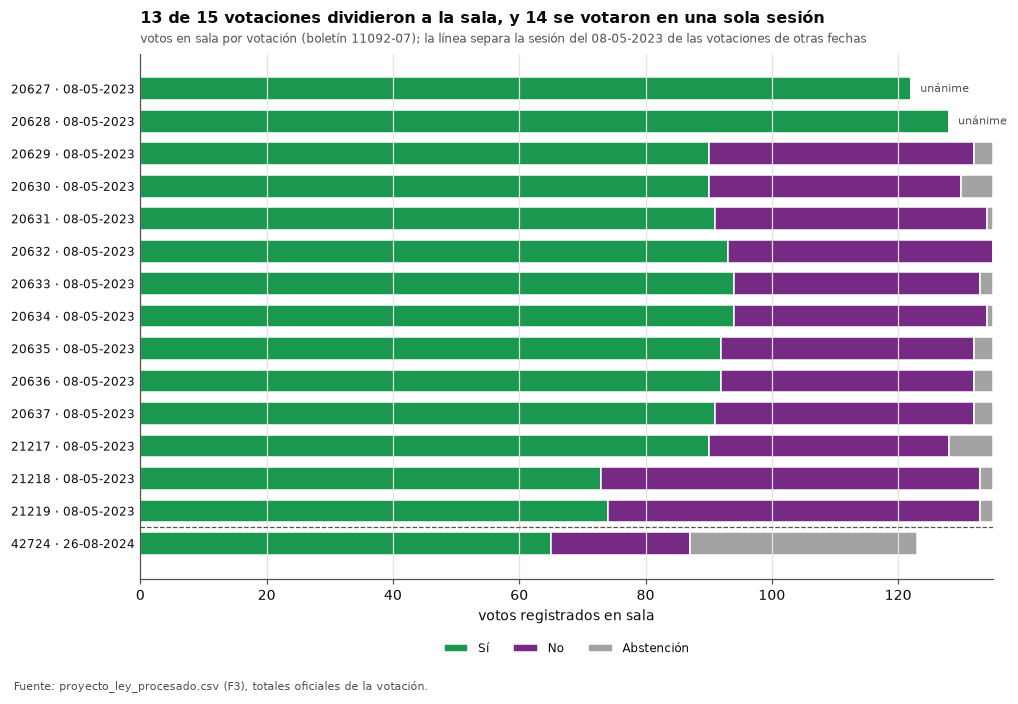

**Lectura de la figura 1.**

- **Qué muestra.** Los votos Sí, No y Abstención registrados en sala en cada una de las 15 votaciones nominales del proyecto, ordenadas por fecha.
- **Qué se infiere.** El conflicto se concentra en las 12 votaciones en particular del segundo trámite, decididas con 73 a 94 votos a favor frente a 38 a 60 en contra, mientras que las votaciones 20627 y 20628 fueron unánimes.
- **Límite.** El corpus es pequeño y está concentrado en el tiempo (14 votaciones en 13 minutos), por lo que no permite estudiar la evolución de las posiciones a lo largo de la tramitación.
- **Aporte al relato.** Delimita el material empírico de las cuatro preguntas: las posiciones y la cohesión que siguen describen el conflicto sobre estas disposiciones, no el comportamiento legislativo general.

In [3]:
# Votaciones que dividieron a la sala: ni unánimes ni de otra fecha.
disputadas_sesion = catalogo.loc[~catalogo['Id'].isin(unanimes)
                                 & catalogo['fecha'].dt.date.eq(sesion_principal)]
fig, ax = plt.subplots(figsize=(10, 6.2))
y = np.arange(len(catalogo))[::-1]
izquierda = np.zeros(len(catalogo))
for categoria, columna in (('Sí', 'TotalSi'), ('No', 'TotalNo'), ('Abstención', 'TotalAbstencion')):
    ax.barh(y, catalogo[columna], left=izquierda, color=vis.VOTOS[categoria], height=0.7,
            edgecolor='white', linewidth=1, label=categoria)
    izquierda += catalogo[columna].to_numpy()
etiquetas = [f"{v} · {f:%d-%m-%Y}" for v, f in zip(catalogo['Id'], catalogo['fecha'])]
ax.set_yticks(y, etiquetas, fontsize=8)
ax.tick_params(axis='y', length=0)
for posicion, total, unanime in zip(y, izquierda, catalogo['Id'].isin(unanimes)):
    if unanime:
        ax.text(total + 1.5, posicion, 'unánime', va='center', fontsize=7.5,
                color=vis.TEXTO_SECUNDARIO)
# Separa la sesión principal de las votaciones de otras fechas.
otras = (~catalogo['fecha'].dt.date.eq(sesion_principal)).to_numpy()
if otras.any():
    ax.axhline(y[otras].max() + 0.5, color=vis.TEXTO_SECUNDARIO, linewidth=0.8,
               linestyle='--')
ax.set_xlabel('votos registrados en sala')
ax.grid(axis='x')
vis.titulo(ax, f'{n_votaciones - len(unanimes)} de {n_votaciones} votaciones dividieron a la sala, '
               f'y {en_sesion_principal} se votaron en una sola sesión',
           f'votos en sala por votación (boletín 11092-07); la línea separa la sesión del '
           f'{sesion_principal:%d-%m-%Y} de las votaciones de otras fechas')
vis.leyenda_inferior(ax, ncol=3, y=-0.1)
vis.nota(fig, 'Fuente: proyecto_ley_procesado.csv (F3), totales oficiales de la votación.',
         y=-0.04)
guardar(fig, '01_votaciones_corpus.png')
plt.show()

lectura(
    1,
    f'Los votos Sí, No y Abstención registrados en sala en cada una de las {n_votaciones} '
    'votaciones nominales del proyecto, ordenadas por fecha.',
    f'El conflicto se concentra en las {len(disputadas_sesion)} votaciones en particular del '
    f'segundo trámite, decididas con {disputadas_sesion["TotalSi"].min()} a '
    f'{disputadas_sesion["TotalSi"].max()} votos a favor frente a '
    f'{disputadas_sesion["TotalNo"].min()} a {disputadas_sesion["TotalNo"].max()} en contra, '
    f'mientras que las votaciones {lista(unanimes)} fueron unánimes.',
    f'El corpus es pequeño y está concentrado en el tiempo ({en_sesion_principal} votaciones '
    f'en {int(duracion.total_seconds() // 60)} minutos), por lo que no permite estudiar la '
    'evolución de las posiciones a lo largo de la tramitación.',
    'Delimita el material empírico de las cuatro preguntas: las posiciones y la cohesión que '
    'siguen describen el conflicto sobre estas disposiciones, no el comportamiento '
    'legislativo general.')

In [4]:
otras_fechas = catalogo.loc[~catalogo['fecha'].dt.date.eq(sesion_principal)]
mixta = otras_fechas.iloc[0]
texto(
    f'El corpus tiene **{n_votaciones} votaciones**. {en_sesion_principal} se realizaron en la '
    f'sesión del {sesion_principal:%d-%m-%Y}, en {int(duracion.total_seconds() // 60)} '
    f'minutos, durante el segundo trámite constitucional. '
    + (f'La restante ({mixta["Id"]}, {mixta["fecha"]:%d-%m-%Y}) es la proposición de la '
       f'Comisión Mixta, aprobada con {mixta["TotalSi"]} votos a favor, {mixta["TotalNo"]} en '
       f'contra y {mixta["TotalAbstencion"]} abstenciones. '
       if len(otras_fechas) == 1 else
       f'Las {len(otras_fechas)} restantes corresponden a otras fechas. ')
    + f'{len(unanimes)} votaciones fueron unánimes '
    f'({lista(unanimes)}): no discriminan entre posiciones y por eso los '
    'métodos de escalamiento las excluyen, mientras que la cohesión y la afinidad las '
    'conservan.')

El corpus tiene **15 votaciones**. 14 se realizaron en la sesión del 08-05-2023, en 13 minutos, durante el segundo trámite constitucional. La restante (42724, 26-08-2024) es la proposición de la Comisión Mixta, aprobada con 65 votos a favor, 22 en contra y 36 abstenciones. 2 votaciones fueron unánimes (20627 y 20628): no discriminan entre posiciones y por eso los métodos de escalamiento las excluyen, mientras que la cohesión y la afinidad las conservan.

### 1.2. Universo de cada método y estado del protocolo
Cada método trabaja sobre su propio universo, definido y aprobado en el acta B04 (puerta G1).
La tabla resume quiénes y qué votaciones entran en cada uno. Además se comprueba que el
protocolo esté aprobado y que la conciliación entre salidas no tenga pendientes.

In [5]:
universo = pd.read_csv(rutas['universo']).set_index('metodo')
columnas_universo = ['rol', 'unidad', 'n_corpus', 'n_incluidos', 'n_excluidos',
                     'motivos_exclusion', 'n_votaciones']
display(universo[columnas_universo])

decisiones = leer_json('decisiones')
conciliacion = leer_json('conciliacion')
estado_protocolo = pd.Series({
    'Protocolo (analisis.toml)': config['protocolo']['estado'],
    'Versión del protocolo': config['protocolo']['version'],
    'Puerta G1 (universos)': decisiones['puertas']['G1']['estado'],
    'Controles de conciliación': ', '.join(f'{k}: {v}'
                                           for k, v in conciliacion['resumen'].items()),
}, name='valor').to_frame()
display(estado_protocolo)
assert config['protocolo']['estado'] == 'aprobado'
assert decisiones['puertas']['G1']['estado'] == 'aprobada'
assert conciliacion['resumen']['pendiente'] == 0

,rol,unidad,n_corpus,n_incluidos,n_excluidos,motivos_exclusion,n_votaciones
metodo,,,,,,,
bcall_automatico,principal,diputado,151,136,15,PARTICIPACION_NO_SUPERA_UMBRAL:15,13
bcall_grupos_externos,complementario,diputado,151,108,43,SIN_CLUSTER:32|PARTICIPACION_NO_SUPERA_UMBRAL:11,13
posicion_partido_votacion,principal,partido_x_votacion,259,194,65,DECISIONES_INSUFICIENTES_PARTIDO_VOTACION:65,13
posicion_partidaria_P_p,principal,partido,22,14,8,VOTACIONES_INSUFICIENTES_PARA_PERFIL_PARTIDARI...,13
cohesion_ai_entropia,principal,partido_x_votacion,298,207,91,T_bajo_minimo:76|grupo_independientes:15,15
cohesion_rice,principal,partido_x_votacion,298,204,94,T_bajo_minimo:76|grupo_independientes:15|binar...,15
cohesion_resumen_partido,principal,partido,23,14,9,votaciones_validas_bajo_minimo:8|grupo_indepen...,15
afinidad_pares,auxiliar,par_de_diputados,11325,9141,2184,COVOTOS_INSUFICIENTES:1761|SIN_COVOTOS:423,15
clustering,contraste_descriptivo,diputado,151,135,16,COBERTURA_INSUFICIENTE:16,13


,valor
Protocolo (analisis.toml),aprobado
Versión del protocolo,0.7.0
Puerta G1 (universos),aprobada
Controles de conciliación,"coincide: 20, explicada: 3, pendiente: 0"


## 2. P1 · Posiciones relativas de diputadas y diputados

### 2.1. Medida
La posición individual se estima con **B-Call** (puerto del paquete R `bcall`). Sea
$x_{ij} \in \{-1, 0, 1\}$ el voto (No, Abstención, Sí) del diputado $i$ en la votación $j$. Cada
votación con varianza se estandariza y se orienta según el grupo del pivote:

$$u_{ij} = s_j\,\frac{x_{ij} - \bar{x}_j}{\sigma_j}, \qquad
d1_i = \frac{1}{m_i}\sum_{j} u_{ij}, \qquad
d2_i = \sqrt{\frac{1}{m_i - 1}\sum_{j}\left(u_{ij} - d1_i\right)^2},$$

donde $s_j \in \{-1, 1\}$ hace que el grupo del pivote quede del lado positivo y $m_i$ es el
número de votaciones con decisión registrada. **d1** es la posición relativa y **d2** la
variabilidad del voto alrededor de esa posición.

- Los dos grupos se forman automáticamente (`bcall_auto`); el diputado 815 es el pivote.
- Entran los diputados con participación mayor al 10 %.
- La clasificación ideológica externa de los partidos no participa en la estimación: solo
  se usa para contrastar el resultado.

In [6]:
bcall = pd.read_csv(rutas['bcall']).set_index('diputado_id')
ejecucion = leer_json('ejecucion_bcall')
perfiles = pd.read_csv(rutas['perfiles'])
pivote = int(ejecucion['pivot'])

assert len(bcall) == universo.at['bcall_automatico', 'n_incluidos'] == ejecucion['incluidos']
assert int(perfiles['diputados'].sum()) == len(bcall)
assert pivote == config['orientacion']['pivot']

lados = bcall['grupo_bcall'].value_counts()
posiciones = bcall.groupby('d1').size()
resumen_lados = bcall.groupby('grupo_bcall').agg(
    diputados=('d1', 'size'), d1_mediana=('d1', 'median'), d1_min=('d1', 'min'),
    d1_max=('d1', 'max'), d2_mediana=('d2', 'median'))
display(resumen_lados)

,diputados,d1_mediana,d1_min,d1_max,d2_mediana
grupo_bcall,,,,,
L,94,-0.726106,-0.862877,0.354577,0.095272
R,42,1.360165,0.854263,1.458364,0.320638


### 2.2. Distribución en el plano d1–d2
Cada burbuja es una coordenada exacta y su área es proporcional al número de diputados que
la comparten. Como el corpus tiene pocas votaciones informativas, los diputados se concentran
en pocos patrones de voto. La tabla siguiente lista los patrones más frecuentes (S = Sí,
N = No, A = Abstención, · = sin registro, en el orden de las votaciones usadas).

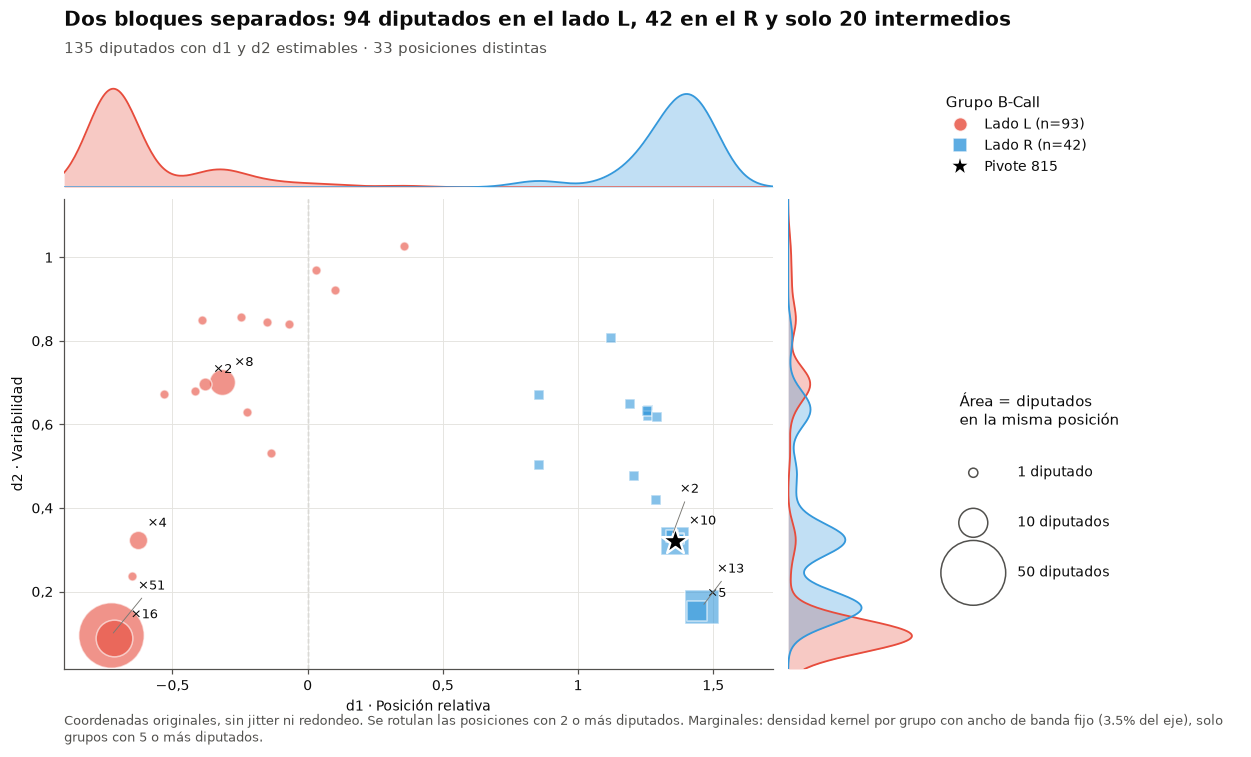

**Lectura de la figura 2.**

- **Qué muestra.** Cada burbuja es una combinación exacta de posición (d1) y variabilidad (d2), con área proporcional al número de diputados que la comparten; las curvas de los márgenes son la densidad de cada lado (1 diputado sin d2, por tener una sola votación utilizable, no aparece en el plano).
- **Qué se infiere.** La distribución es bimodal y disciplinada: las 4 coordenadas con 10 o más diputados reúnen a 90 de los 135 diputados (67 %); de los 20 que quedan entre ambos polos, 19 combinan Sí y No en distintas disposiciones.
- **Límite.** El eje es relativo a las 13 votaciones informativas de este proyecto: los lados L y R no son una clasificación ideológica, y las posiciones son pocas y discretas porque los patrones de voto se repiten.
- **Aporte al relato.** Responde P1 y anticipa P2: el eje horizontal separa dos bloques y el vertical identifica a los diputados que se apartan de ellos.

,patron,diputados,d1,d2,grupo,partidos
0,SSSSSSSSSSSSS,51,-0.726106,0.095272,L,"PC (9), IND (8), PS (7), PCS / FA (5), DC (4),..."
1,SSSSSSSSSSSS·,16,-0.714709,0.089775,L,"PS (5), IND (4), PC (2), PCS (2), RD (1), PR (..."
2,NNNNNNNNNNNNN,13,1.458364,0.163694,R,"PREP (6), UDI (3), IND (2), UDI / IND (1), RN ..."
3,NNNNNNNNNNNNA,10,1.360165,0.320638,R,"UDI (6), IND (2), PREP / IND (1), PRI (1)"
4,SSSSSSSSSSNNA,8,-0.317352,0.702703,L,"RN (6), IND (2)"
5,NNNNNNNNNNNN·,5,1.439037,0.154706,R,"IND (3), PREP (2)"
6,SSSSSSSSSSSSA,4,-0.627907,0.324555,L,"IND (3), PDG (1)"
7,SSSSSSSSSSNN·,2,-0.378273,0.697170,L,RN (2)
8,NANNNNNNNNNN·,2,1.347674,0.333867,R,RN (2)
9,············S,1,-0.862877,NaN,L,PC / IND (1)


In [7]:
etiquetas_lado = {'L': 'Lado L', 'R': 'Lado R'}
n_intermedios = int(bcall['d1'].abs().lt(0.5).sum())
fig, ax = vis.plano_bcall(
    bcall, 'grupo_bcall', pivote,
    f'Dos bloques separados: {lados["L"]} diputados en el lado L, {lados["R"]} en el R '
    f'y solo {n_intermedios} intermedios',
    'Grupo B-Call', etiquetas=etiquetas_lado)
guardar(fig, '02_plano_d1_d2.png')
plt.show()

coordenadas = bcall.dropna(subset=['d2']).groupby(['d1', 'd2']).size().sort_values(
    ascending=False)
pobladas = coordenadas.loc[coordenadas.ge(10)]
n_informativas = int(votaciones_bcall['incluida_por_varianza'].sum())
patrones_intermedios = perfiles.loc[perfiles['d1'].abs().lt(0.5)]
cruzan_entre_polos = int(patrones_intermedios.loc[
    patrones_intermedios['patron'].str.contains('S')
    & patrones_intermedios['patron'].str.contains('N'), 'diputados'].sum())
lectura(
    2,
    'Cada burbuja es una combinación exacta de posición (d1) y variabilidad (d2), con área '
    'proporcional al número de diputados que la comparten; las curvas de los márgenes son la '
    'densidad de cada lado'
    + (f' ({int(bcall["d2"].isna().sum())} diputado sin d2, por tener una sola votación '
       'utilizable, no aparece en el plano).' if bcall['d2'].isna().any() else '.'),
    f'La distribución es bimodal y disciplinada: las {len(pobladas)} coordenadas con 10 o más '
    f'diputados reúnen a {int(pobladas.sum())} de los {int(coordenadas.sum())} diputados '
    f'({pct(pobladas.sum() / coordenadas.sum())}); de los {n_intermedios} que quedan entre '
    f'ambos polos, {cruzan_entre_polos} combinan Sí y No en distintas disposiciones.',
    f'El eje es relativo a las {n_informativas} votaciones informativas de este proyecto: '
    'los lados L y R no son una clasificación ideológica, y las posiciones son pocas y '
    'discretas porque los patrones de voto se repiten.',
    'Responde P1 y anticipa P2: el eje horizontal separa dos bloques y el vertical identifica '
    'a los diputados que se apartan de ellos.')

display(perfiles.head(10)[['patron', 'diputados', 'd1', 'd2', 'grupo', 'partidos']])

In [8]:
extremos = perfiles.groupby('grupo').head(1).set_index('grupo')
intermedios = bcall.loc[bcall['d1'].abs().lt(0.5)]
# Partidos de los diputados intermedios, desde la columna «partidos» de cada patrón.
conteo_intermedios = (
    perfiles.loc[perfiles['d1'].abs().lt(0.5), ['partidos', 'diputados']]
    .assign(partido=lambda t: t['partidos'].str.findall(r'([^,()]+?) \((\d+)\)'))
    .explode('partido').dropna(subset=['partido'])
    .assign(n=lambda t: t['partido'].str[1].astype(int),
            partido=lambda t: t['partido'].str[0].str.strip())
    .groupby('partido')['n'].sum().sort_values(ascending=False))
assert int(conteo_intermedios.sum()) == len(intermedios)
cruzan_intermedios = perfiles.loc[perfiles['d1'].abs().lt(0.5)
                                  & perfiles['patron'].str.contains('S')
                                  & perfiles['patron'].str.contains('N'), 'diputados'].sum()
texto(
    f'B-Call ubica a **{len(bcall)} diputados** en {len(posiciones)} posiciones distintas de d1. '
    f'El lado L reúne a {lados["L"]} diputados ({pct(lados["L"] / len(bcall))}) y el lado R a '
    f'{lados["R"]} ({pct(lados["R"] / len(bcall))}). La distribución es **bimodal y muy '
    f'concentrada**: el patrón más frecuente del lado L ({extremos.at["L", "patron"]}, '
    f'{extremos.at["L", "diputados"]} diputados) está en d1 = {c(extremos.at["L", "d1"])}, y el '
    f'del lado R ({extremos.at["R", "patron"]}, {extremos.at["R", "diputados"]} diputados) en '
    f'd1 = {c(extremos.at["R", "d1"])}. Entre ambos polos hay **{len(intermedios)} diputados '
    f'con |d1| < 0,5**; {cruzan_intermedios} de ellos votan Sí y No en distintas '
    'disposiciones. Por partido: '
    + ', '.join(f'{p} ({n})' for p, n in conteo_intermedios.items()) + '.')

B-Call ubica a **136 diputados** en 34 posiciones distintas de d1. El lado L reúne a 94 diputados (69 %) y el lado R a 42 (31 %). La distribución es **bimodal y muy concentrada**: el patrón más frecuente del lado L (SSSSSSSSSSSSS, 51 diputados) está en d1 = −0,73, y el del lado R (NNNNNNNNNNNNN, 13 diputados) en d1 = 1,46. Entre ambos polos hay **20 diputados con |d1| < 0,5**; 19 de ellos votan Sí y No en distintas disposiciones. Por partido: RN (12), IND (4), EVOP (2), IND / PSC (1), PSC (1).

### 2.3. Validez y robustez de las posiciones
La posición individual se contrasta con métodos y supuestos alternativos:

- **Métodos alternativos.** Clustering jerárquico sobre Hamming (C07) y PCA/SVD (F4_04).
- **Validez externa.** Cotejo de los grupos automáticos con la clasificación externa de
  partidos, con su versión registrada.
- **Supuestos del modelo.**
  - Cambio de pivote, entre todos los pivotes elegibles.
  - Retiro de los casos frontera de la referencia externa.
  - Retiro de una votación por vez (`sensibilidad.csv`).

Un ARI de 1 indica particiones idénticas. Las correlaciones comparan d1 con la primera
componente principal (PC1) alineada en signo.

In [9]:
comparacion = pd.read_csv(rutas['comparacion']).iloc[0]
sens_clustering = pd.read_csv(rutas['sensibilidad_clustering']).set_index('escenario')
sens_pca = pd.read_csv(rutas['sensibilidad_pca'])
sensibilidad = pd.read_csv(rutas['sensibilidad'])
complementarios = ejecucion['analisis_complementarios']

# Una fila por diputado y votación retirada: la diferencia no depende del umbral.
sens_d1 = sensibilidad.loc[sensibilidad['metodo'].eq('bcall_d1')
                           & sensibilidad['umbral_cobertura'].eq(
                               sensibilidad['umbral_cobertura'].min())]
retiro_votacion = sens_clustering.loc[sens_clustering.index.str.startswith('retiro_votacion')]
bloque = sens_clustering.loc[sens_clustering.index.str.startswith('retiro_bloque')].iloc[0]
pca_retiro = sens_pca.loc[sens_pca['escenario'].str.startswith('retiro_votacion')]

robustez_individual = pd.DataFrame([
    ('Clustering (Hamming, enlace promedio) vs grupos B-Call', 'ARI',
     c(comparacion['ari_clustering_bcall'], 3), f"{int(comparacion['n_comunes_clustering'])} diputados"),
    ('PCA: PC1 alineada vs d1', 'Pearson / Spearman',
     f"{c(comparacion['pearson_pc1_alineado_d1'], 4)} / {c(comparacion['spearman_pc1_alineado_d1'], 4)}",
     f"{int(comparacion['n_comunes_pca'])} diputados (casos completos)"),
    ('Cotejo con la clasificación externa', 'concordancia por fila',
     c(ejecucion['concordancia_por_fila'], 3), f"{ejecucion['filas_comparables_cotejo']} filas"),
    ('Sin casos frontera (PDG, Demócratas)', 'concordancia por fila',
     c(complementarios['escenario_sin_casos_frontera']['concordancia_por_fila'], 3), 'escenario externo'),
    ('Cambio de pivote', 'pivotes con el mismo eje',
     f"{complementarios['pivotes_con_mismo_eje']} de {complementarios['pivotes_elegibles']}", 'pivotes elegibles'),
    ('Retiro de una votación: d1', 'máx. |Δd1| · cambios de signo',
     f"{c(sens_d1['diferencia_abs'].max(), 3)} · {int(sens_d1['cambio_signo'].eq(True).sum())}",
     f"{sens_d1['votacion_retirada'].nunique()} escenarios"),
    ('Retiro de una votación: clustering', 'ARI mínimo',
     c(retiro_votacion['ari'].min(), 3), f'{len(retiro_votacion)} escenarios'),
    ('Retiro de una votación: PCA', 'Pearson |PC1| mínimo',
     c(pca_retiro['pearson_abs_pc1'].min(), 4), f'{len(pca_retiro)} escenarios'),
    ('Retiro del bloque de artículos 20629–20637', 'ARI del clustering',
     c(bloque['ari'], 3), f"{int(bloque['n_cambios_grupo'])} cambios de grupo"),
], columns=['contraste', 'medida', 'valor', 'base'])
display(robustez_individual)
assert comparacion['ari_clustering_bcall'] == 1.0

,contraste,medida,valor,base
0,"Clustering (Hamming, enlace promedio) vs grupo...",ARI,"1,000",135 diputados
1,PCA: PC1 alineada vs d1,Pearson / Spearman,"0,9999 / 0,9985",107 diputados (casos completos)
2,Cotejo con la clasificación externa,concordancia por fila,"0,827",1479 filas
3,"Sin casos frontera (PDG, Demócratas)",concordancia por fila,"0,844",escenario externo
4,Cambio de pivote,pivotes con el mismo eje,25 de 25,pivotes elegibles
5,Retiro de una votación: d1,máx. |Δd1| · cambios de signo,"0,185 · 6",15 escenarios
6,Retiro de una votación: clustering,ARI mínimo,"0,970",15 escenarios
7,Retiro de una votación: PCA,Pearson |PC1| mínimo,"0,9985",26 escenarios
8,Retiro del bloque de artículos 20629–20637,ARI del clustering,"0,461",17 cambios de grupo


In [10]:
ids_bloque = {int(v) for v in config['sensibilidad']['clustering_bloques']['articulos_206xx']}
informativas = set(votaciones_bcall.index[votaciones_bcall['incluida_por_varianza']])
sin_bloque = catalogo.loc[catalogo['Id'].isin(informativas - ids_bloque)]
texto(
    'Las posiciones individuales son **robustas al método y a los supuestos**. El clustering '
    f'reproduce exactamente los dos grupos (ARI = {c(comparacion["ari_clustering_bcall"], 1)}) '
    f'y la PC1 está casi perfectamente correlacionada con d1 (r = '
    f'{c(comparacion["pearson_pc1_alineado_d1"], 4)}). Los '
    f'{complementarios["pivotes_elegibles"]} pivotes elegibles producen el mismo eje. Retirar '
    f'una votación cambia d1 a lo sumo en {c(sens_d1["diferencia_abs"].max(), 3)} y solo en '
    f'{int(sens_d1["cambio_signo"].eq(True).sum())} casos invierte el lado de un diputado.\n\n'
    f'La excepción es el **bloque de {len(ids_bloque)} votaciones sobre los artículos 14 ter a '
    f'31** ({min(ids_bloque)}–{max(ids_bloque)}). Al retirarlo, el clustering cambia de grupo a '
    f'{int(bloque["n_cambios_grupo"])} diputados (ARI = {c(bloque["ari"], 3)}). Esto no es '
    f'inestabilidad del método: ese bloque reúne {len(ids_bloque)} de las '
    f'{len(informativas)} votaciones informativas. Sin él solo quedan {len(sin_bloque)} '
    '(' + '; '.join(f'{v}: {d}' for v, d in zip(sin_bloque['Id'], sin_bloque['disposicion']))
    + '), y la división pasa a depender de ellas. La posición relativa describe, por tanto, '
    'el conflicto sobre el conjunto de disposiciones votadas, con predominio de ese bloque.')

Las posiciones individuales son **robustas al método y a los supuestos**. El clustering reproduce exactamente los dos grupos (ARI = 1,0) y la PC1 está casi perfectamente correlacionada con d1 (r = 0,9999). Los 25 pivotes elegibles producen el mismo eje. Retirar una votación cambia d1 a lo sumo en 0,185 y solo en 6 casos invierte el lado de un diputado.

La excepción es el **bloque de 9 votaciones sobre los artículos 14 ter a 31** (20629–20637). Al retirarlo, el clustering cambia de grupo a 17 diputados (ARI = 0,461). Esto no es inestabilidad del método: ese bloque reúne 9 de las 13 votaciones informativas. Sin él solo quedan 4 (21217: Artículo 32; 21218: Letra b) del artículo 35; 21219: Letra c) del artículo 35; 42724: Proposición de la Comisión Mixta recaída en el proyecto de ley), y la división pasa a depender de ellas. La posición relativa describe, por tanto, el conflicto sobre el conjunto de disposiciones votadas, con predominio de ese bloque.

### 2.4. Respuesta a P1

In [11]:
texto(
    f'> **P1.** Los diputados se ordenan en un eje relativo con **dos bloques claramente '
    f'separados**: {lados["L"]} en el lado L y {lados["R"]} en el lado R. Hay pocas posiciones '
    f'intermedias ({len(intermedios)} diputados con |d1| < 0,5). La posición se explica por el '
    'voto sobre las disposiciones en disputa (artículos 14 ter a 35 y la proposición de la '
    'Comisión Mixta). Es la misma con métodos alternativos y con distintos pivotes, y '
    'coincide en su mayoría con la clasificación externa de los partidos (concordancia '
    f'{pct(ejecucion["concordancia_por_fila"])}). Es una posición **relativa a este proyecto**: '
    'no constituye una medida ideológica general.')

> **P1.** Los diputados se ordenan en un eje relativo con **dos bloques claramente separados**: 94 en el lado L y 42 en el lado R. Hay pocas posiciones intermedias (20 diputados con |d1| < 0,5). La posición se explica por el voto sobre las disposiciones en disputa (artículos 14 ter a 35 y la proposición de la Comisión Mixta). Es la misma con métodos alternativos y con distintos pivotes, y coincide en su mayoría con la clasificación externa de los partidos (concordancia 83 %). Es una posición **relativa a este proyecto**: no constituye una medida ideológica general.

## 3. P2 · Estabilidad y variabilidad del comportamiento individual

### 3.1. Medida y alcance
La variabilidad individual se mide con **d2**: la desviación estándar muestral de los votos
estandarizados y orientados $u_{ij}$ alrededor de la posición propia $d1_i$. Un d2 bajo indica
que el diputado vota de forma consistente con un mismo lado del eje en todas las votaciones; un
d2 alto, que alterna entre lados. Dos precisiones son necesarias para interpretarla:

- **Un perfil constante no tiene d2 = 0.** Cada votación se estandariza con su propia media y
  desviación. Por eso un diputado que vota igual en todas las votaciones tiene $u_{ij}$
  distintos y un d2 pequeño, pero positivo. Para identificar el comportamiento invariable se
  usan además los patrones de voto observados.
- **"A lo largo de las votaciones" no es lo mismo que "a lo largo del tiempo".** Casi todo el
  corpus se votó en una sola sesión (sección 1.1). La estabilidad se evalúa entre votaciones
  de esa sesión y la de la Comisión Mixta. **El corpus no permite estimar trayectorias ni
  cambios de posición en el tiempo**: no hay una secuencia de sesiones suficiente para
  separar el cambio temporal del contenido de cada votación.

La estabilidad del comportamiento (d2) es distinta de la **robustez del método** (sección
2.3). La segunda evalúa cuánto cambian las estimaciones al alterar los supuestos; la primera,
cuánto varía el voto de cada persona.

In [12]:
d2 = bcall['d2'].dropna()
revision = pd.read_csv(rutas['posiciones_revision'])
alta_variabilidad = revision.loc[revision['criterio'].eq('d2_cuartil_superior')]
corte_d2 = d2.quantile(0.75)
assert len(alta_variabilidad) == int(d2.ge(corte_d2).sum())

# Patrón constante: todas las decisiones registradas son iguales (se ignora «·»).
perfiles['decisiones_distintas'] = perfiles['patron'].str.replace('·', '').map(set).map(len)
constantes = int(perfiles.loc[perfiles['decisiones_distintas'].eq(1), 'diputados'].sum())
con_abstencion = int(perfiles.loc[perfiles['patron'].str.contains('A')
                                  & perfiles['decisiones_distintas'].eq(2)
                                  & ~(perfiles['patron'].str.contains('S')
                                      & perfiles['patron'].str.contains('N')), 'diputados'].sum())
cruzan = int(perfiles.loc[perfiles['patron'].str.contains('S')
                          & perfiles['patron'].str.contains('N'), 'diputados'].sum())
assert constantes + con_abstencion + cruzan == len(bcall)

tipos_perfil = pd.Series({
    'Mismo voto en todas las votaciones': constantes,
    'Un solo lado, con alguna abstención': con_abstencion,
    'Votan Sí y No (cruzan el eje)': cruzan,
}, name='diputados').to_frame()
tipos_perfil['proporción'] = (tipos_perfil['diputados'] / len(bcall)).map(pct)
display(tipos_perfil)
display(bcall.groupby('grupo_bcall')['d2'].describe()[['count', '25%', '50%', '75%', 'max']])

,diputados,proporción
Mismo voto en todas las votaciones,86,63 %
"Un solo lado, con alguna abstención",23,17 %
Votan Sí y No (cruzan el eje),27,20 %


,count,25%,50%,75%,max
grupo_bcall,,,,,
L,93.0,0.095272,0.095272,0.324555,1.027634
R,42.0,0.163694,0.320638,0.333867,0.807455


### 3.2. Distribución de d2
La figura muestra la distribución acumulada de d2 por lado del eje. La línea punteada marca
el cuartil superior, que se usa como criterio descriptivo de alta variabilidad. No es un
umbral normativo.

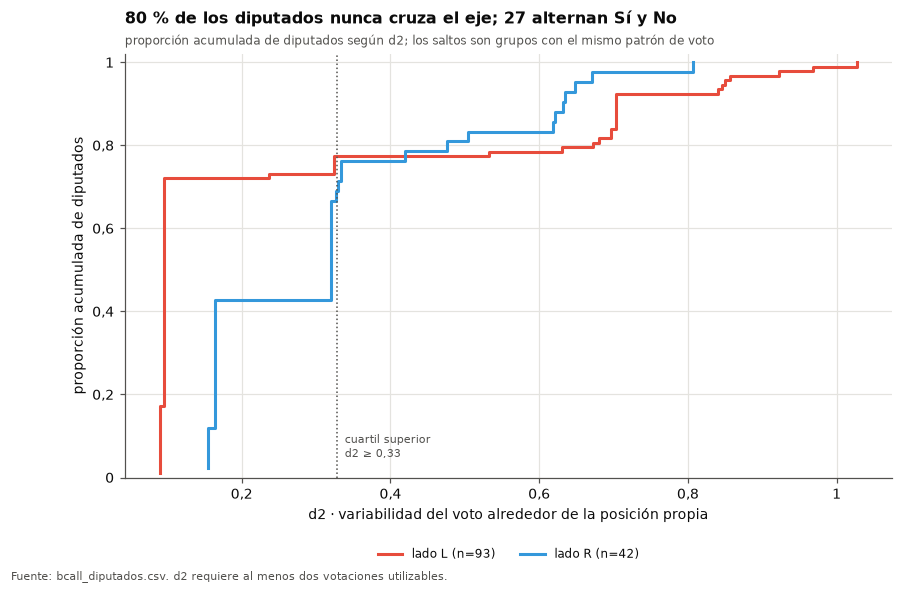

**Lectura de la figura 3.**

- **Qué muestra.** La proporción acumulada de diputados de cada lado según su variabilidad d2, con el cuartil superior como referencia descriptiva.
- **Qué se infiere.** En el lado L la mayoría tiene el d2 mínimo (mediana 0,10); en el R la mediana es mayor (0,32) porque 19 de sus 42 integrantes combinan el No con alguna abstención. El cuartil superior (d2 ≥ 0,33) reúne a 34 diputados, de los cuales 27 votan Sí y No en distintas disposiciones.
- **Límite.** d2 no vale 0 con un perfil constante y su escala depende de la estandarización de cada votación, por eso se lee junto con los patrones de voto; además mide consistencia entre disposiciones de una misma sesión, no estabilidad en el tiempo.
- **Aporte al relato.** Responde P2: la estabilidad individual es la norma y la variabilidad es propia de un grupo acotado, que la figura 4 vincula con la zona central del eje partidario.

In [13]:
cruzan_alta_fig = int((alta_variabilidad['patron'].str.contains('S')
                       & alta_variabilidad['patron'].str.contains('N')).sum())
fig, ax = plt.subplots(figsize=(9, 5))
for lado in ('L', 'R'):
    valores = np.sort(bcall.loc[bcall['grupo_bcall'].eq(lado), 'd2'].dropna())
    ax.step(valores, np.arange(1, len(valores) + 1) / len(valores), where='post',
            color=vis.GRUPOS[lado], linewidth=2, label=f'lado {lado} (n={len(valores)})')
ax.axvline(corte_d2, color=vis.TEXTO_SECUNDARIO, linestyle=':', linewidth=1)
ax.text(corte_d2, 0.04, f'  cuartil superior\n  d2 ≥ {c(corte_d2)}', fontsize=7.5,
        color=vis.TEXTO_SECUNDARIO, va='bottom')
ax.set_xlabel('d2 · variabilidad del voto alrededor de la posición propia')
ax.set_ylabel('proporción acumulada de diputados')
ax.set_ylim(0, 1.02)
ax.grid(True)
vis.formato_coma(ax, 'x')
vis.formato_coma(ax, 'y')
vis.titulo(ax, f'{pct((constantes + con_abstencion) / len(bcall))} de los diputados nunca '
               f'cruza el eje; {cruzan} alternan Sí y No',
           'proporción acumulada de diputados según d2; los saltos son grupos con el mismo '
           'patrón de voto')
vis.leyenda_inferior(ax, ncol=2, y=-0.14)
vis.nota(fig, 'Fuente: bcall_diputados.csv. d2 requiere al menos dos votaciones utilizables.',
         y=-0.06)
guardar(fig, '03_variabilidad_d2.png')
plt.show()

mediana_lado = bcall.groupby('grupo_bcall')['d2'].median()
perfiles_r = perfiles.loc[perfiles['grupo'].eq('R')]
r_con_abstencion = int(perfiles_r.loc[perfiles_r['patron'].str.contains('A'), 'diputados'].sum())
lectura(
    3,
    'La proporción acumulada de diputados de cada lado según su variabilidad d2, con el '
    'cuartil superior como referencia descriptiva.',
    f'En el lado L la mayoría tiene el d2 mínimo (mediana {c(mediana_lado["L"])}); en el R la '
    f'mediana es mayor ({c(mediana_lado["R"])}) porque {r_con_abstencion} de sus '
    f'{int(perfiles_r["diputados"].sum())} integrantes combinan el No con alguna abstención. '
    f'El cuartil superior (d2 ≥ {c(corte_d2)}) '
    f'reúne a {len(alta_variabilidad)} diputados, de los cuales {cruzan_alta_fig} votan Sí y '
    'No en distintas disposiciones.',
    'd2 no vale 0 con un perfil constante y su escala depende de la estandarización de cada '
    'votación, por eso se lee junto con los patrones de voto; además mide consistencia entre '
    'disposiciones de una misma sesión, no estabilidad en el tiempo.',
    'Responde P2: la estabilidad individual es la norma y la variabilidad es propia de un '
    'grupo acotado, que la figura 4 vincula con la zona central del eje partidario.')

### 3.3. Variabilidad y cambios de partido
Durante el período, algunos diputados cambian de militancia. Un cambio de afiliación no
implica un cambio de comportamiento: la tabla compara d2 entre quienes cambian de partido y
quienes no lo hacen. También muestra los diputados con mayor variabilidad y su patrón de voto.

In [14]:
cambiantes = {int(d['diputado_id']): ' → '.join(d['partidos'])
              for d in conciliacion['partidos_cambiantes']['detalle']}
bcall['cambia_partido'] = bcall.index.isin(cambiantes)
d2_por_cambio = bcall.groupby('cambia_partido')['d2'].agg(['count', 'median', 'mean', 'max'])
d2_por_cambio.index = d2_por_cambio.index.map({True: 'cambia de partido',
                                               False: 'mismo partido'})
display(d2_por_cambio)

columnas = ['diputado', 'partidos', 'grupo_bcall', 'd1', 'd2', 'm_i', 'patron']
display(alta_variabilidad.sort_values('d2', ascending=False)[columnas].head(15))

,count,median,mean,max
cambia_partido,,,,
mismo partido,116,0.159200,0.296445,1.027634
cambia de partido,19,0.095272,0.144784,0.532049


,diputado,partidos,grupo_bcall,d1,d2,m_i,patron
3,Miguel Ángel Becker,RN,L,0.354577,1.027634,13,SNNSSSSSNNNNA
4,José Miguel Castro,RN,L,0.031300,0.968439,13,NASSSSSSSSNNN
5,Jorge Guzmán,EVOP,L,0.099781,0.922549,13,NNASSSSSSSNNA
6,Francisco Undurraga,EVOP,L,-0.246881,0.856180,13,SNSSSSSSSSNNS
7,Natalia Romero,IND,L,-0.389457,0.850457,13,SNSSSNSSSSSSS
8,Marcia Raphael,RN,L,-0.151234,0.846344,13,NSSSSSSSSSNNA
9,Paula Labra,IND,L,-0.069602,0.839879,13,ASNSSSSSSSNNA
10,Cristóbal Martínez,UDI,R,1.120717,0.807455,13,NNNNSNSNNNNNN
11,Juan Carlos Beltrán,RN,L,-0.317352,0.702703,13,SSSSSSSSSSNNA
12,Frank Sauerbaum,RN,L,-0.317352,0.702703,13,SSSSSSSSSSNNA


### 3.4. Respuesta a P2

In [15]:
mediana_d2 = d2.median()
cambio_mediana = d2_por_cambio['median']
cruzan_alta = int(revision.loc[revision['criterio'].eq('d2_cuartil_superior')
                               & revision['patron'].str.contains('S')
                               & revision['patron'].str.contains('N')].shape[0])
texto(
    f'> **P2.** El comportamiento individual es **mayoritariamente estable**: '
    f'{pct(constantes / len(bcall))} de los diputados emite el mismo voto en todas las '
    f'votaciones en que participa, y {pct(con_abstencion / len(bcall))} solo agrega '
    f'abstenciones sin cruzar el eje. La variabilidad se concentra en **{cruzan} diputados '
    f'({pct(cruzan / len(bcall))}) que votan Sí y No** en distintas disposiciones: '
    f'{cruzan_intermedios} de ellos están en el centro del eje (|d1| < 0,5) y '
    + ('todos' if cruzan_alta == cruzan else str(cruzan_alta))
    + f' pertenecen al cuartil superior de d2 (d2 ≥ {c(corte_d2)}; mediana general '
    f'{c(mediana_d2)}). Los '
    f'{int(bcall["cambia_partido"].sum())} diputados que cambian de '
    f'partido no son más variables (mediana de d2 {c(cambio_mediana["cambia de partido"])} '
    f'frente a {c(cambio_mediana["mismo partido"])}). **Límite:** como '
    f'{en_sesion_principal} de las {n_votaciones} votaciones ocurrieron en una sola sesión, la '
    'estabilidad describe la consistencia entre disposiciones votadas, no la evolución de las '
    'posiciones durante la tramitación.')

> **P2.** El comportamiento individual es **mayoritariamente estable**: 63 % de los diputados emite el mismo voto en todas las votaciones en que participa, y 17 % solo agrega abstenciones sin cruzar el eje. La variabilidad se concentra en **27 diputados (20 %) que votan Sí y No** en distintas disposiciones: 19 de ellos están en el centro del eje (|d1| < 0,5) y todos pertenecen al cuartil superior de d2 (d2 ≥ 0,33; mediana general 0,15). Los 20 diputados que cambian de partido no son más variables (mediana de d2 0,10 frente a 0,16). **Límite:** como 14 de las 15 votaciones ocurrieron en una sola sesión, la estabilidad describe la consistencia entre disposiciones votadas, no la evolución de las posiciones durante la tramitación.

## 4. P3 · Posiciones relativas de los partidos

### 4.1. Medida
La posición partidaria se agrega en dos etapas sobre los mismos votos orientados $u_{ij}$ de
B-Call:

$$b_{pj} = \frac{1}{|I_{pj}|}\sum_{i \in I_{pj}} u_{ij}, \qquad
P_p = \frac{1}{|J_p|}\sum_{j \in J_p} b_{pj}.$$

- $I_{pj}$ es el conjunto de integrantes del partido $p$ con decisión en la votación $j$,
  según el **partido vigente en esa fecha**.
- $J_p$ es el conjunto de votaciones en que el partido reúne al menos 2 decisiones.
- Cada votación pesa lo mismo, y se exigen al menos 2 votaciones para publicar $P_p$.

La dispersión interna se describe con la mediana y el rango intercuartílico (RIQ) de d1 de
sus integrantes. **IND no es un partido**: su $P_p$ se calcula, pero no se publica (A03-012),
porque promedia independientes ubicados en los dos extremos del eje.

In [16]:
posicion = pd.read_csv(rutas['posicion'])
partidos = posicion.loc[posicion['nivel'].eq('partido')].copy()
partidos['publicable'] = partidos['publicable'].astype(str).str.lower().eq('true')
publicables = partidos.loc[partidos['publicable']].sort_values('P_p')
assert len(publicables) == universo.at['posicion_partidaria_P_p', 'n_incluidos']

display(publicables[['partido_alias', 'partido_nombre', 'P_p', 'n_votaciones', 'n_diputados',
                     'mediana_d1', 'iqr_d1']].set_index('partido_alias'))
display(partidos.loc[~partidos['publicable'],
                     ['partido_alias', 'P_p', 'n_votaciones', 'n_diputados',
                      'razon_no_publicable']].set_index('partido_alias'))

,partido_nombre,P_p,n_votaciones,n_diputados,mediana_d1,iqr_d1
partido_alias,,,,,,
PS,Partido Socialista,-0.726106,13.0,12,-0.726106,0.011398
PAH,Partido Acción Humanista,-0.726106,13.0,2,-0.726106,0.000000
PL,Partido Liberal de Chile,-0.726106,13.0,2,-0.726106,0.000000
PC,Partido Comunista,-0.726106,13.0,11,-0.726106,0.000000
DC,Partido Demócrata Cristiano,-0.726106,13.0,4,-0.726106,0.000000
PPD,Partido Por la Democracia,-0.726106,13.0,3,-0.726106,0.005699
PCS,Partido Convergencia Social,-0.714709,12.0,7,-0.726106,0.005699
RD,Revolución Democrática,-0.714709,12.0,4,-0.726106,0.002849
PR,Partido Radical de Chile,-0.714709,12.0,2,-0.720407,0.005699


,P_p,n_votaciones,n_diputados,razon_no_publicable
partido_alias,,,,
IND,-0.131459,13.0,40,GRUPO_INDEPENDIENTES
PEV,NaN,0.0,1,VOTACIONES_INSUFICIENTES_PARA_PERFIL_PARTIDARIO
FA,NaN,1.0,10,VOTACIONES_INSUFICIENTES_PARA_PERFIL_PARTIDARIO
PSC,NaN,1.0,2,VOTACIONES_INSUFICIENTES_PARA_PERFIL_PARTIDARIO
DEM,NaN,1.0,3,VOTACIONES_INSUFICIENTES_PARA_PERFIL_PARTIDARIO
COMUNES,NaN,0.0,1,VOTACIONES_INSUFICIENTES_PARA_PERFIL_PARTIDARIO
FRVS,NaN,0.0,1,VOTACIONES_INSUFICIENTES_PARA_PERFIL_PARTIDARIO
PRI,NaN,0.0,1,VOTACIONES_INSUFICIENTES_PARA_PERFIL_PARTIDARIO


### 4.2. Posición y heterogeneidad interna
El panel izquierdo compara $P_p$ con la mediana de d1 de los integrantes del partido. Si ambas
coinciden, el partido vota como bloque. El panel derecho muestra el RIQ de d1, es decir, la
dispersión de las posiciones individuales dentro del partido.

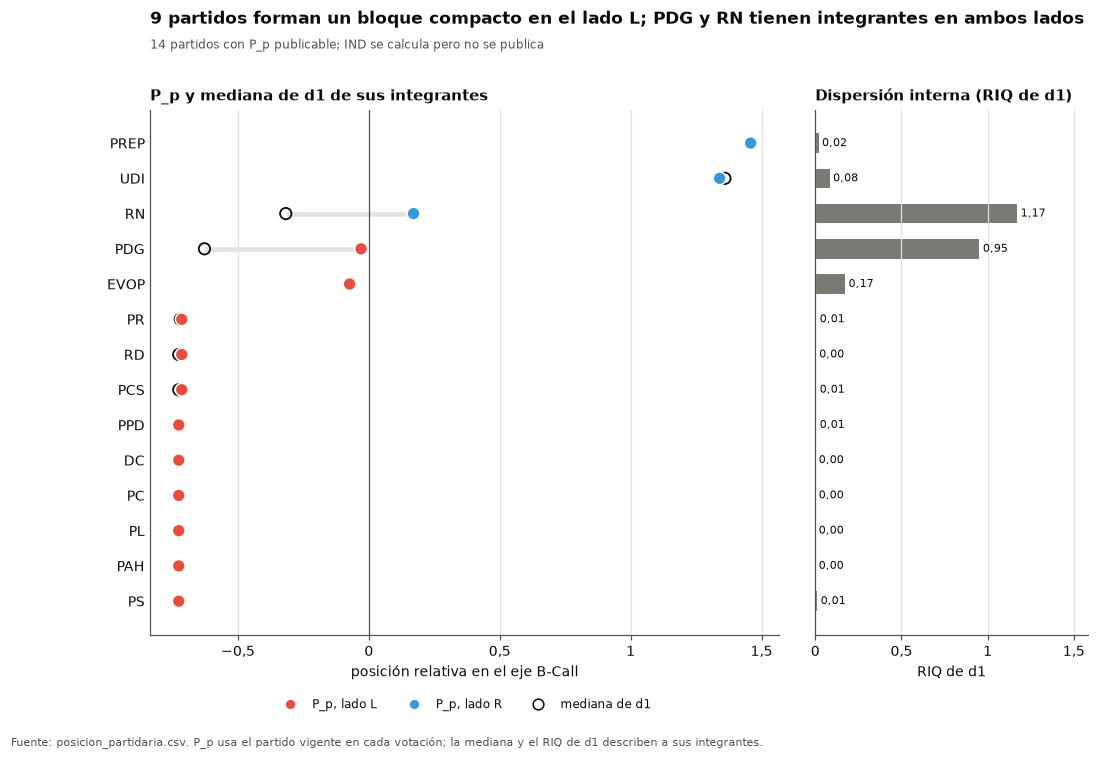

**Lectura de la figura 4.**

- **Qué muestra.** Para cada partido con P_p publicable, su posición agregada (punto lleno), la mediana de d1 de sus integrantes (círculo vacío) y, a la derecha, el RIQ de d1 como dispersión interna.
- **Qué se infiere.** Donde P_p y la mediana coinciden y el RIQ es casi nulo, el partido vota como bloque (9 partidos del lado L, además de UDI y PREP en el R); en PDG y RN la distancia entre ambos marcadores y un RIQ de 0,95 y 1,17 muestran que su posición intermedia promedia integrantes de lados opuestos.
- **Límite.** P_p se publica solo para 14 partidos (7 no tienen votaciones suficientes e IND no es un partido), usa el partido vigente en cada votación y hereda el carácter relativo del eje B-Call.
- **Aporte al relato.** Responde P3 y conecta con P4: los partidos con integrantes en ambos lados del eje son los que muestran menor cohesión en la figura 5.

In [17]:
y = np.arange(len(publicables))
n_bloque_l = int(publicables['P_p'].lt(-0.5).sum())
divididos = publicables.loc[publicables['P_p'].abs().le(0.5)
                            & publicables['iqr_d1'].ge(0.5), 'partido_alias'].tolist()
fig, (ax, ax_riq) = plt.subplots(1, 2, figsize=(11, 6.2), sharey=True,
                                 gridspec_kw={'width_ratios': (3, 1.3), 'wspace': 0.08})
colores = [vis.GRUPOS['L' if v < 0 else 'R'] for v in publicables['P_p']]
ax.hlines(y, publicables[['P_p', 'mediana_d1']].min(axis=1),
          publicables[['P_p', 'mediana_d1']].max(axis=1), color=vis.GRILLA, linewidth=3, zorder=1)
ax.scatter(publicables['P_p'], y, s=70, color=colores, zorder=3, edgecolors='white')
ax.scatter(publicables['mediana_d1'], y, s=55, facecolors='none', edgecolors=vis.TEXTO,
           linewidths=1.2, zorder=2)
ax.axvline(0, color=vis.TEXTO_SECUNDARIO, linewidth=0.8)
ax.set_yticks(y, publicables['partido_alias'])
ax.tick_params(axis='y', length=0)
ax.set_xlabel('posición relativa en el eje B-Call')
ax.grid(axis='x')
vis.formato_coma(ax, 'x')
fig.text(0.125, 1.0, f'{n_bloque_l} partidos forman un bloque compacto en el lado L; '
         f'{lista(divididos)} tienen integrantes en ambos lados', fontsize=11,
         fontweight='bold', color=vis.TEXTO, ha='left', va='bottom')
fig.text(0.125, 0.965, f'{len(publicables)} partidos con P_p publicable; IND se calcula pero '
         'no se publica', fontsize=8, color=vis.TEXTO_SECUNDARIO, ha='left', va='bottom')
ax.set_title('P_p y mediana de d1 de sus integrantes', fontsize=9.5)
vis.leyenda_inferior(ax, [vis.marcador(vis.GRUPOS['L'], 'P_p, lado L'),
                          vis.marcador(vis.GRUPOS['R'], 'P_p, lado R'),
                          plt.Line2D([], [], linestyle='', marker='o', markersize=7,
                                     markerfacecolor='none', markeredgecolor=vis.TEXTO,
                                     label='mediana de d1')], ncol=3, y=-0.1)

ax_riq.barh(y, publicables['iqr_d1'], color=vis.NEUTRO, height=0.55)
for posicion_y, valor in zip(y, publicables['iqr_d1']):
    ax_riq.text(valor + 0.02, posicion_y, c(valor), va='center', fontsize=7.5,
                color=vis.TEXTO)
ax_riq.set_xlim(0, publicables['iqr_d1'].max() * 1.35)
ax_riq.set_xlabel('RIQ de d1')
ax_riq.tick_params(axis='y', length=0)
ax_riq.grid(axis='x')
vis.formato_coma(ax_riq, 'x')
ax_riq.set_title('Dispersión interna (RIQ de d1)', fontsize=9.5)
vis.nota(fig, 'Fuente: posicion_partidaria.csv. P_p usa el partido vigente en cada votación; '
              'la mediana y el RIQ de d1 describen a sus integrantes.', y=-0.04)
guardar(fig, '04_posicion_partidos.png')
plt.show()

bloque_r_fig = publicables.loc[publicables['P_p'].gt(0.5), 'partido_alias'].tolist()
iqr_divididos = publicables.set_index('partido_alias').loc[divididos, 'iqr_d1']
lectura(
    4,
    'Para cada partido con P_p publicable, su posición agregada (punto lleno), la mediana de '
    'd1 de sus integrantes (círculo vacío) y, a la derecha, el RIQ de d1 como dispersión '
    'interna.',
    f'Donde P_p y la mediana coinciden y el RIQ es casi nulo, el partido vota como bloque '
    f'({n_bloque_l} partidos del lado L, además de {lista(bloque_r_fig)} en el R); en '
    f'{lista(divididos)} '
    f'la distancia entre ambos marcadores y un RIQ de {lista(c(v) for v in iqr_divididos)} '
    'muestran que su posición intermedia promedia integrantes de lados opuestos.',
    f'P_p se publica solo para {len(publicables)} partidos '
    f'({int(partidos["P_p"].isna().sum())} no tienen votaciones suficientes e IND no es un '
    'partido), usa el partido vigente en cada votación y hereda el carácter relativo del eje '
    'B-Call.',
    'Responde P3 y conecta con P4: los partidos con integrantes en ambos lados del eje son los '
    'que muestran menor cohesión en la figura 5.')

### 4.3. Robustez de la posición partidaria
`sensibilidad.csv` vuelve a estimar B-Call y $P_p$ retirando una votación por vez. La tabla
resume, para los partidos publicables, el mayor cambio absoluto de $P_p$ y si el partido
cambia de lado del eje o de lugar en el orden.

In [18]:
sens_pp = sensibilidad.loc[sensibilidad['metodo'].eq('perfil_partidario_P_p')
                           & sensibilidad['umbral_cobertura'].eq(
                               sensibilidad['umbral_cobertura'].min())
                           & sensibilidad['id'].isin(publicables['partido_id'])]
robustez_partidos = (sens_pp.groupby('id')
                     .agg(max_delta_P_p=('diferencia_abs', 'max'),
                          cambios_signo=('cambio_signo', lambda s: int(s.eq(True).sum())),
                          desplazamiento_orden_max=('desplazamiento_orden', 'max'))
                     .join(publicables.set_index('partido_id')[['partido_alias', 'P_p']])
                     .set_index('partido_alias').sort_values('P_p'))
display(robustez_partidos)

,max_delta_P_p,cambios_signo,desplazamiento_orden_max,P_p
partido_alias,,,,
DC,0.015441,0,1.5,-0.726106
PAH,0.015441,0,1.5,-0.726106
PC,0.015441,0,1.5,-0.726106
PPD,0.015441,0,1.5,-0.726106
PL,0.015441,0,1.5,-0.726106
PS,0.015441,0,1.5,-0.726106
PR,0.017880,0,3.0,-0.714709
PCS,0.017880,0,3.0,-0.714709
RD,0.017880,0,3.0,-0.714709


### 4.4. Respuesta a P3

In [19]:
pub = publicables.set_index('partido_alias')
bloque_l = pub.loc[pub['P_p'].lt(-0.5)]
centro = pub.loc[pub['P_p'].abs().le(0.5)]
bloque_r = pub.loc[pub['P_p'].gt(0.5)]
# Zona central: dividida entre integrantes (RIQ alto) o dentro de cada integrante.
entre_integrantes = centro.loc[centro['iqr_d1'].ge(0.5)].index
dentro_integrantes = centro.loc[centro['iqr_d1'].lt(0.5)].index
sin_p_p = partidos.loc[partidos['P_p'].isna()]
cambio_lado = robustez_partidos.loc[robustez_partidos['cambios_signo'].gt(0)].index
texto(
    f'> **P3.** Los {len(pub)} partidos con posición publicable se distribuyen en **tres '
    f'zonas**. (i) Un bloque L compacto de {len(bloque_l)} partidos '
    f'({", ".join(bloque_l.index)}) con P_p entre {c(bloque_l["P_p"].min())} y '
    f'{c(bloque_l["P_p"].max())}, prácticamente sin dispersión interna (RIQ de d1 ≤ '
    f'{c(bloque_l["iqr_d1"].max())}). (ii) Un bloque R de {len(bloque_r)} partidos '
    f'({", ".join(bloque_r.index)}) con P_p ≥ {c(bloque_r["P_p"].min())}. (iii) Una zona '
    f'central ({", ".join(centro.index)}) cuyo P_p cercano a 0 no expresa una posición común. '
    + (f'En {lista(entre_integrantes)} los integrantes se ubican en lados distintos del eje '
       '(RIQ de d1 ' + lista(c(pub.at[p, "iqr_d1"]) for p in entre_integrantes) + '). '
       if len(entre_integrantes) else '')
    + (f'En {lista(dentro_integrantes)} los propios integrantes alternan entre lados '
       '(d1 individual intermedio y RIQ bajo). ' if len(dentro_integrantes) else '')
    + f'Retirar una votación cambia P_p a lo sumo en '
    f'{c(robustez_partidos["max_delta_P_p"].max(), 3)}; '
    + (f'solo {", ".join(cambio_lado)}, con P_p cercano a 0, cambia de lado en algún escenario.'
       if len(cambio_lado) else 'ningún partido cambia de lado.')
    + f' {len(sin_p_p)} partidos no tienen P_p por tener menos de 2 votaciones con celda '
    'incluida.')

> **P3.** Los 14 partidos con posición publicable se distribuyen en **tres zonas**. (i) Un bloque L compacto de 9 partidos (PS, PAH, PL, PC, DC, PPD, PCS, RD, PR) con P_p entre −0,73 y −0,71, prácticamente sin dispersión interna (RIQ de d1 ≤ 0,01). (ii) Un bloque R de 2 partidos (UDI, PREP) con P_p ≥ 1,34. (iii) Una zona central (EVOP, PDG, RN) cuyo P_p cercano a 0 no expresa una posición común. En PDG y RN los integrantes se ubican en lados distintos del eje (RIQ de d1 0,95 y 1,17). En EVOP los propios integrantes alternan entre lados (d1 individual intermedio y RIQ bajo). Retirar una votación cambia P_p a lo sumo en 0,131; solo PDG, con P_p cercano a 0, cambia de lado en algún escenario. 7 partidos no tienen P_p por tener menos de 2 votaciones con celda incluida.

## 5. P4 · Cohesión y dispersión de los partidos

### 5.1. Medidas
La cohesión se calcula por partido y votación sobre la **vista nominal** (Sí, No, Abstención).
Usa el partido vigente en cada fecha y las 15 votaciones, incluidas las unánimes. Con
$Y, N, A$ los votos de cada opción y $T = Y + N + A$:

$$AI = \frac{\max(Y, N, A) - \tfrac{1}{2}\,(T - \max(Y, N, A))}{T}, \qquad
Rice = \frac{|Y - N|}{Y + N}, \qquad
C^H = 1 - \frac{-\sum_k q_k \ln q_k}{\ln 3}.$$

- **Agreement Index** ($AI$; Hix, Noury y Roland, 2005): es el índice principal.
- **Índice de Rice** (1925): contraste que ignora las abstenciones.
- **Cohesión entrópica** ($C^H$; Shannon, 1948): segundo contraste, con $q_k$ la proporción
  de cada opción.
- Los tres valen 1 cuando el partido vota unido.
- **Resumen por partido:** la mediana entre votaciones, publicable si el partido tiene al
  menos 2 votaciones con 2 o más decisiones.
- **Medida complementaria:** la proporción de desacuerdo entre pares de integrantes del mismo
  partido (Hamming intrapartido, `hamming_partidos.csv`). Captura el disenso aunque sea de
  pocos integrantes.

In [20]:
cohesion = pd.read_csv(rutas['resumen_cohesion'])
cohesion['publicable_resumen'] = cohesion['publicable_resumen'].astype(str).str.lower().eq('true')
cohesion_pub = cohesion.loc[cohesion['publicable_resumen']].set_index('partido_alias')
assert len(cohesion_pub) == universo.at['cohesion_resumen_partido', 'n_incluidos']

hamming = pd.read_csv(rutas['hamming_partidos'])
intra = hamming.loc[hamming['partido_a'].eq(hamming['partido_b'])].set_index('partido_a')
cohesion_pub = cohesion_pub.join(intra[['hamming', 'n_comparaciones']]
                                 .rename(columns={'hamming': 'hamming_intrapartido'}))
cohesion_pub = cohesion_pub.join(pub[['P_p', 'iqr_d1']], how='left')
tabla_cohesion = cohesion_pub[['n_validas_ai', 'mediana_ai', 'min_ai', 'mediana_rice',
                               'mediana_entropia', 'mediana_ai_sin_unanimes',
                               'hamming_intrapartido', 'iqr_d1', 'P_p']]
display(tabla_cohesion.sort_values('mediana_ai'))
display(cohesion.loc[~cohesion['publicable_resumen'],
                     ['partido_alias', 'tipo_grupo', 'n_votaciones_observadas',
                      'razon_no_publicable_resumen']].set_index('partido_alias'))

,n_validas_ai,mediana_ai,min_ai,mediana_rice,mediana_entropia,mediana_ai_sin_unanimes,hamming_intrapartido,iqr_d1,P_p
partido_alias,,,,,,,,,
PDG,14,0.500000,0.000000,0.333333,0.420620,0.500000,0.547619,0.952420,-0.029688
RN,15,0.558824,0.382353,0.500000,0.409029,0.558824,0.351693,1.171615,0.170635
UDI,15,0.916667,0.382353,1.000000,0.804700,0.916667,0.116762,0.083599,1.339696
DC,15,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,-0.726106
PC,15,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,-0.726106
PCS,14,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.005699,-0.714709
PAH,15,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,-0.726106
EVOP,15,1.000000,0.250000,1.000000,1.000000,1.000000,0.200000,0.173331,-0.073550
PPD,14,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.005699,-0.726106


,tipo_grupo,n_votaciones_observadas,razon_no_publicable_resumen
partido_alias,,,
COMUNES,partido,12,votaciones_validas_bajo_minimo
DEM,partido,1,votaciones_validas_bajo_minimo
FA,partido,1,votaciones_validas_bajo_minimo
FRVS,partido,15,votaciones_validas_bajo_minimo
IND,independientes,15,grupo_independientes
PEV,partido,14,votaciones_validas_bajo_minimo
PH,partido,1,votaciones_validas_bajo_minimo
PRI,partido,15,votaciones_validas_bajo_minimo
PSC,partido,15,votaciones_validas_bajo_minimo


### 5.2. Cohesión por partido
Cada panel muestra una medida, con el mismo orden de partidos (de menor a mayor Agreement
Index). Los tres índices miden unidad: 1 indica voto unánime del partido. El cuarto panel mide
desacuerdo: 0 indica que ningún par de integrantes votó distinto.

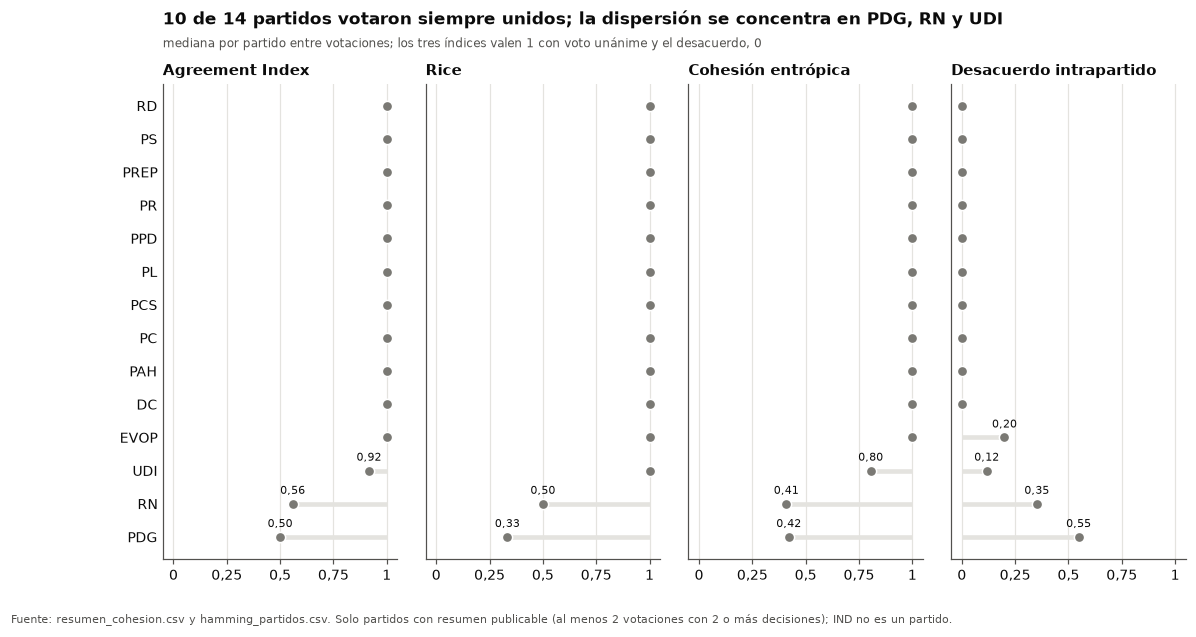

**Lectura de la figura 5.**

- **Qué muestra.** Para cada partido con resumen publicable, la mediana entre votaciones de tres índices de cohesión (1 = voto unánime) y la proporción de desacuerdo entre pares de integrantes (0 = sin desacuerdo).
- **Qué se infiere.** La cohesión es casi máxima: solo PDG, RN y UDI se apartan de 1 en el Agreement Index, el desacuerdo intrapartido revela además disenso puntual en EVOP, y en UDI la dispersión proviene de abstenciones, que Rice no registra porque solo considera Sí y No.
- **Límite.** Los partidos de uno o dos integrantes y con pocas votaciones disputadas alcanzan el máximo casi por construcción (efecto techo), y la mediana entre votaciones puede ocultar disensos aislados que solo capta el desacuerdo intrapartido.
- **Aporte al relato.** Responde P4 y cierra el relato: en este proyecto el comportamiento legislativo es bipolar y disciplinado, con la disidencia concentrada en pocos partidos.

In [21]:
unidos = tabla_cohesion.loc[tabla_cohesion['mediana_ai'].eq(1)
                            & tabla_cohesion['hamming_intrapartido'].eq(0)]
menos_cohesion = tabla_cohesion.loc[tabla_cohesion['mediana_ai'].lt(1)].sort_values(
    'mediana_ai').index.tolist()
orden = tabla_cohesion.sort_values(['mediana_ai', 'hamming_intrapartido'],
                                   ascending=[True, False]).index
paneles = [('mediana_ai', 'Agreement Index'), ('mediana_rice', 'Rice'),
           ('mediana_entropia', 'Cohesión entrópica'),
           ('hamming_intrapartido', 'Desacuerdo intrapartido')]
fig, ejes = plt.subplots(1, 4, figsize=(12, 5.6), sharey=True, gridspec_kw={'wspace': 0.12})
y = np.arange(len(orden))
for ax, (columna, nombre) in zip(ejes, paneles):
    valores = tabla_cohesion.loc[orden, columna]
    base = 1.0 if columna != 'hamming_intrapartido' else 0.0
    ax.hlines(y, base, valores, color=vis.GRILLA, linewidth=3, zorder=1)
    ax.scatter(valores, y, s=45, color=vis.NEUTRO, zorder=3, edgecolors='white')
    for posicion_y, valor in zip(y, valores):
        if pd.notna(valor) and abs(valor - base) > 1e-9:
            ax.text(valor, posicion_y + 0.3, c(valor), ha='center', fontsize=7,
                    color=vis.TEXTO)
    ax.set_xlim(-0.05, 1.05)
    ax.grid(axis='x')
    vis.formato_coma(ax, 'x')
    ax.set_title(nombre, fontsize=9.5)
    ax.tick_params(axis='y', length=0)
ejes[0].set_yticks(y, orden)
fig.suptitle(f'{len(unidos)} de {len(tabla_cohesion)} partidos votaron siempre unidos; la '
             f'dispersión se concentra en {lista(menos_cohesion)}', x=0.125, ha='left',
             fontweight='bold', fontsize=11, y=1.0)
fig.text(0.125, 0.94, 'mediana por partido entre votaciones; los tres índices valen 1 con '
         'voto unánime y el desacuerdo, 0', fontsize=8, color=vis.TEXTO_SECUNDARIO)
vis.nota(fig, 'Fuente: resumen_cohesion.csv y hamming_partidos.csv. Solo partidos con resumen '
              'publicable (al menos 2 votaciones con 2 o más decisiones); IND no es un partido.',
         y=0.02)
guardar(fig, '05_cohesion_partidos.png')
plt.show()

disenso_puntual = tabla_cohesion.loc[tabla_cohesion['mediana_ai'].eq(1)
                                     & tabla_cohesion['hamming_intrapartido'].gt(0)].index
sin_rice = tabla_cohesion.loc[tabla_cohesion['mediana_ai'].lt(1)
                              & tabla_cohesion['mediana_rice'].eq(1)].index
lectura(
    5,
    'Para cada partido con resumen publicable, la mediana entre votaciones de tres índices de '
    'cohesión (1 = voto unánime) y la proporción de desacuerdo entre pares de integrantes '
    '(0 = sin desacuerdo).',
    f'La cohesión es casi máxima: solo {lista(menos_cohesion)} se apartan de 1 en el Agreement '
    'Index'
    + (f', el desacuerdo intrapartido revela además disenso puntual en '
       f'{lista(disenso_puntual)}' if len(disenso_puntual) else '')
    + (f', y en {lista(sin_rice)} la dispersión proviene de abstenciones, que Rice no '
       'registra porque solo considera Sí y No' if len(sin_rice) else '') + '.',
    'Los partidos de uno o dos integrantes y con pocas votaciones disputadas alcanzan el máximo '
    'casi por construcción (efecto techo), y la mediana entre votaciones puede ocultar '
    'disensos aislados que solo capta el desacuerdo intrapartido.',
    'Responde P4 y cierra el relato: en este proyecto el comportamiento legislativo es bipolar '
    'y disciplinado, con la disidencia concentrada en pocos partidos.')

### 5.3. Robustez de la cohesión
Se comparan los resúmenes base con tres escenarios definidos antes de calcular:

- retirar una votación por vez;
- retirar las votaciones unánimes;
- exigir al menos 3 decisiones por partido y votación.

In [22]:
sens_ai = sensibilidad.loc[sensibilidad['metodo'].eq('mediana_agreement_index')
                           & sensibilidad['umbral_cobertura'].eq(
                               sensibilidad['umbral_cobertura'].min())
                           & sensibilidad['publicable_base'].astype(str).str.lower().eq('true')]
robustez_cohesion = sens_ai.groupby('escenario').agg(
    partidos=('id', 'nunique'), max_delta_AI=('diferencia_abs', 'max'),
    cambios_publicabilidad=('cambio_publicabilidad', lambda s: int(s.eq(True).sum())))
display(robustez_cohesion)

,partidos,max_delta_AI,cambios_publicabilidad
escenario,,,
minimo_decisiones_3,14,0.0,4
retiro_una_votacion,14,0.0,0
sin_votaciones_unanimes,14,0.0,0


### 5.4. Respuesta a P4

In [23]:
perfectos = tabla_cohesion.loc[tabla_cohesion['mediana_ai'].eq(1)
                               & tabla_cohesion['hamming_intrapartido'].eq(0)]
dispersos = tabla_cohesion.loc[tabla_cohesion['mediana_ai'].lt(1)].sort_values('mediana_ai')
casi = tabla_cohesion.loc[tabla_cohesion['mediana_ai'].eq(1)
                          & tabla_cohesion['hamming_intrapartido'].gt(0)]
dispersos_centro = [p for p in dispersos.index if p in centro.index]
dispersos_otros = [p for p in dispersos.index if p not in centro.index]
rice_completo = dispersos.loc[dispersos['mediana_rice'].eq(1)].index
delta_unanimes = robustez_cohesion.at['sin_votaciones_unanimes', 'max_delta_AI']
texto(
    f'> **P4.** La cohesión partidaria es **alta y casi máxima**: {len(perfectos)} de los '
    f'{len(tabla_cohesion)} partidos con resumen publicable votaron unidos en todas las '
    f'votaciones (AI = 1 y ningún desacuerdo interno). La dispersión se concentra en '
    f'**{lista(f"{p} (AI = {c(v)})" for p, v in dispersos["mediana_ai"].items())}**. '
    + (f'{" y ".join(dispersos_centro)} coinciden con la zona central del eje en P3: su '
       'posición promedio intermedia proviene de votos divididos. ' if dispersos_centro else '')
    + (f'En {", ".join(dispersos_otros)}, del bloque R, el disenso es puntual. '
       if dispersos_otros else '')
    + (f'En {", ".join(casi.index)} la mediana es 1, pero hay disenso en alguna votación '
       f'(desacuerdo intrapartido {", ".join(c(v) for v in casi["hamming_intrapartido"])}). '
       if len(casi) else '')
    + 'La cohesión entrópica identifica los mismos partidos'
    + (f'; Rice no detecta la dispersión de {", ".join(rice_completo)}, que proviene de '
       'abstenciones, ya que Rice solo considera Sí y No. ' if len(rice_completo) else '. ')
    + ('Retirar las votaciones unánimes no cambia ningún resumen. ' if delta_unanimes == 0
       else f'Retirar las votaciones unánimes cambia el AI a lo sumo en {c(delta_unanimes, 3)}. ')
    + '**Cautela:** el máximo frecuente refleja también partidos pequeños y pocas votaciones '
    'disputadas (efecto techo); no se publican los partidos con menos de 2 votaciones con 2 '
    'o más decisiones.')

> **P4.** La cohesión partidaria es **alta y casi máxima**: 10 de los 14 partidos con resumen publicable votaron unidos en todas las votaciones (AI = 1 y ningún desacuerdo interno). La dispersión se concentra en **PDG (AI = 0,50), RN (AI = 0,56) y UDI (AI = 0,92)**. PDG y RN coinciden con la zona central del eje en P3: su posición promedio intermedia proviene de votos divididos. En UDI, del bloque R, el disenso es puntual. En EVOP la mediana es 1, pero hay disenso en alguna votación (desacuerdo intrapartido 0,20). La cohesión entrópica identifica los mismos partidos; Rice no detecta la dispersión de UDI, que proviene de abstenciones, ya que Rice solo considera Sí y No. Retirar las votaciones unánimes no cambia ningún resumen. **Cautela:** el máximo frecuente refleja también partidos pequeños y pocas votaciones disputadas (efecto techo); no se publican los partidos con menos de 2 votaciones con 2 o más decisiones.

## 6. Respuesta al objetivo general
La tabla integra las cuatro respuestas, con la evidencia principal, su robustez y su límite.

In [24]:
respuestas = pd.DataFrame([
    ('P1 · Posición individual',
     f'Dos bloques separados ({lados["L"]} L, {lados["R"]} R) y pocas posiciones intermedias '
     f'({len(intermedios)})',
     'd1 de B-Call (bcall_diputados.csv)',
     f'ARI clustering {c(comparacion["ari_clustering_bcall"], 1)}; r PC1 '
     f'{c(comparacion["pearson_pc1_alineado_d1"], 4)}; {complementarios["pivotes_con_mismo_eje"]} '
     'pivotes con el mismo eje',
     'Eje relativo al proyecto; depende del bloque 20629–20637'),
    ('P2 · Estabilidad individual',
     f'{pct((constantes + con_abstencion) / len(bcall))} sin cruzar el eje; {cruzan} diputados '
     'alternan Sí y No',
     'd2 de B-Call y patrones de voto',
     f'mediana de d2 {c(mediana_d2)}; cambio de partido sin mayor variabilidad',
     f'{en_sesion_principal} de {n_votaciones} votaciones en una sesión: sin trayectoria temporal'),
    ('P3 · Posición partidaria',
     f'Bloque L ({len(bloque_l)}), bloque R ({len(bloque_r)}) y zona central heterogénea '
     f'({", ".join(centro.index)})',
     'P_p y RIQ de d1 (posicion_partidaria.csv)',
     f'máx. |ΔP_p| {c(robustez_partidos["max_delta_P_p"].max(), 3)} al retirar una votación',
     f'IND no publicado; {len(sin_p_p)} partidos sin votaciones suficientes'),
    ('P4 · Cohesión partidaria',
     f'{len(perfectos)} de {len(tabla_cohesion)} partidos unánimes; dispersión en '
     f'{", ".join(dispersos.index)}',
     'AI, Rice y entropía (resumen_cohesion.csv); desacuerdo intrapartido',
     'mismos partidos con AI y entropía; sin cambios al retirar las unánimes',
     'Efecto techo en partidos pequeños'),
], columns=['pregunta', 'respuesta', 'evidencia', 'robustez', 'límite'])
display(respuestas.set_index('pregunta'))

,respuesta,evidencia,robustez,límite
pregunta,,,,
P1 · Posición individual,"Dos bloques separados (94 L, 42 R) y pocas pos...",d1 de B-Call (bcall_diputados.csv),"ARI clustering 1,0; r PC1 0,9999; 25 pivotes c...",Eje relativo al proyecto; depende del bloque 2...
P2 · Estabilidad individual,80 % sin cruzar el eje; 27 diputados alternan ...,d2 de B-Call y patrones de voto,"mediana de d2 0,15; cambio de partido sin mayo...",14 de 15 votaciones en una sesión: sin trayect...
P3 · Posición partidaria,"Bloque L (9), bloque R (2) y zona central hete...",P_p y RIQ de d1 (posicion_partidaria.csv),"máx. |ΔP_p| 0,131 al retirar una votación",IND no publicado; 7 partidos sin votaciones su...
P4 · Cohesión partidaria,"10 de 14 partidos unánimes; dispersión en PDG,...","AI, Rice y entropía (resumen_cohesion.csv); de...",mismos partidos con AI y entropía; sin cambios...,Efecto techo en partidos pequeños


In [25]:
texto(
    'En conjunto, la tramitación del proyecto en la Cámara muestra un **conflicto '
    'bipolar y disciplinado**. Las posiciones individuales y partidarias forman dos bloques '
    'estables, los partidos votan mayoritariamente unidos y la variabilidad se concentra en '
    f'un grupo acotado de diputados ({cruzan}) y en {len(dispersos)} partidos con votos '
    f'divididos ({", ".join(dispersos.index)}). El conflicto se localiza en las disposiciones '
    'votadas en particular durante el segundo trámite (artículos 14 ter a 35): las '
    f'votaciones {lista(unanimes)} fueron unánimes, y la proposición de la '
    f'Comisión Mixta se aprobó con {mixta["TotalAbstencion"]} abstenciones.')

En conjunto, la tramitación del proyecto en la Cámara muestra un **conflicto bipolar y disciplinado**. Las posiciones individuales y partidarias forman dos bloques estables, los partidos votan mayoritariamente unidos y la variabilidad se concentra en un grupo acotado de diputados (27) y en 3 partidos con votos divididos (PDG, RN, UDI). El conflicto se localiza en las disposiciones votadas en particular durante el segundo trámite (artículos 14 ter a 35): las votaciones 20627 y 20628 fueron unánimes, y la proposición de la Comisión Mixta se aprobó con 36 abstenciones.

## 7. Limitaciones
1. **Sin padrón verificable.** No se distingue la ausencia justificada de la inasistencia. Las
   coberturas son descriptivas y no se interpretan como asistencia (A03-005, A03-008).
2. **Eje relativo.** d1, $P_p$ y PC1 ordenan a los diputados respecto del conflicto de este
   proyecto. Los lados L y R son etiquetas del eje, no clasificaciones ideológicas.
3. **Corpus pequeño y concentrado.** Hay 15 votaciones, 13 de ellas informativas para B-Call,
   y 14 en una sola sesión. No es posible estudiar la evolución temporal, y las posiciones son
   pocas y discretas (los patrones de voto se repiten).
4. **Dependencia de un bloque de disposiciones.** Las votaciones 20629–20637 concentran el
   conflicto. Sin ellas, el agrupamiento cambia de forma sustantiva.
5. **Partidos pequeños e independientes.** Varios partidos no tienen votaciones suficientes
   para $P_p$ (sección 4), y la cohesión de partidos con uno o dos integrantes tiende al
   máximo por construcción. IND se describe individualmente, no como grupo.
6. **Afiliación histórica.** Algunos diputados cambian de partido. Cada voto se asigna al
   partido vigente en su fecha, sin reasignar al partido actual.

## 8. Reproducibilidad
Se registran el commit del repositorio, el entorno, el corte F3 y las figuras generadas. El
notebook no escribe tablas: solo figuras en `F4/figures/comunicacion/`.

In [26]:
def _git(*args):
    try:
        return subprocess.run(['git', *args], cwd=raiz, capture_output=True, text=True,
                              check=True).stdout.strip()
    except (OSError, subprocess.CalledProcessError):
        return None


estado_git = _git('--no-optional-locks', 'status', '--porcelain') or ''
display(pd.Series({
    'Commit del repositorio': _git('rev-parse', 'HEAD'),
    # El propio notebook cambia al ejecutarse, por eso no cuenta como modificación.
    'Otros archivos modificados': (
        [linea for linea in estado_git.splitlines() if not linea.endswith('.ipynb')]
        or 'ninguno'),
    'Python': platform.python_version(),
    'pandas': pd.__version__,
    'matplotlib': matplotlib.__version__,
    'Commit del corte F3': manifiesto['reproducibilidad']['commit_git'],
    'Protocolo': f"{config['protocolo']['version']} ({config['protocolo']['estado']})",
    'Semilla del protocolo': config['reproducibilidad']['semilla'],
}, name='valor').to_frame())
display(pd.Series(figuras_generadas, name='figuras generadas').to_frame())
# Llegar aquí implica que todas las comprobaciones anteriores se cumplieron.
print('F4_06_APROBADO=True')

,valor
Commit del repositorio,96cfb3a4972771c8ac55dca49310a0073e61a879
Otros archivos modificados,"[M F4/docs/convenciones_notebooks.md, M F4/fi..."
Python,3.12.13
pandas,3.0.5
matplotlib,3.11.1
Commit del corte F3,022d4d0ac3d453430e1473ac603ef5ee0ca29d9f
Protocolo,0.7.0 (aprobado)
Semilla del protocolo,42


,figuras generadas
0,01_votaciones_corpus.png
1,02_plano_d1_d2.png
2,03_variabilidad_d2.png
3,04_posicion_partidos.png
4,05_cohesion_partidos.png


F4_06_APROBADO=True


## 9. Síntesis
- **P1.** Los diputados se ordenan en dos bloques separados del eje relativo del proyecto.
  Hay pocas posiciones intermedias, y el orden se repite con clustering, PCA y distintos
  pivotes.
- **P2.** El comportamiento individual es mayoritariamente invariable. La variabilidad se
  concentra en un grupo acotado que vota Sí y No en distintas disposiciones. El corpus no
  permite evaluar trayectorias temporales.
- **P3.** Los partidos forman un bloque L compacto, un bloque R y una zona central cuya
  posición promedio refleja heterogeneidad interna, no una posición intermedia común.
- **P4.** La cohesión es casi máxima en la mayoría de los partidos. La dispersión se
  concentra en los partidos de la zona central y con disenso interno.
- Todos los resultados son **descriptivos**: provienen de un protocolo aprobado, con
  universos auditados, conciliación sin pendientes y sensibilidad documentada.

## Referencias
- Hix, S., Noury, A. y Roland, G. (2005). Power to the parties: cohesion and competition in
  the European Parliament, 1979–2001. *British Journal of Political Science*, 35(2), 209–234.
- Rice, S. A. (1925). The behavior of legislative groups: a method of measurement.
  *Political Science Quarterly*, 40(1), 60–72.
- Shannon, C. E. (1948). A mathematical theory of communication. *Bell System Technical
  Journal*, 27(3), 379–423.
- Paquete `bcall` para R: https://github.com/bcallr/bcall (commit registrado en
  `analisis.toml`, `[bcall].commit_referencia`).